In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('US-pumpkins.csv')
df.head()

,City Name,Type,Package,Variety,Sub Variety,Grade,Date,Low Price,High Price,Mostly Low,...,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Repack,Trans Mode,Unnamed: 24,Unnamed: 25
0,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,4/29/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
1,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,5/6/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
2,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
3,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
4,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,11/5/16,90.0,100.0,90.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN


### Data Summary


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1757 entries, 0 to 1756
Data columns (total 26 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   City Name        1757 non-null   str    
 1   Type             45 non-null     str    
 2   Package          1757 non-null   str    
 3   Variety          1752 non-null   str    
 4   Sub Variety      296 non-null    str    
 5   Grade            0 non-null      float64
 6   Date             1757 non-null   str    
 7   Low Price        1757 non-null   float64
 8   High Price       1757 non-null   float64
 9   Mostly Low       1654 non-null   float64
 10  Mostly High      1654 non-null   float64
 11  Origin           1754 non-null   str    
 12  Origin District  131 non-null    str    
 13  Item Size        1478 non-null   str    
 14  Color            1141 non-null   str    
 15  Environment      0 non-null      float64
 16  Unit of Sale     162 non-null    str    
 17  Quality          0 non-nu

In [4]:
df.describe()

,Grade,Low Price,High Price,Mostly Low,Mostly High,Environment,Quality,Condition,Appearance,Storage,Crop,Trans Mode,Unnamed: 24
count,0.0,1757.000000,1757.000000,1654.000000,1654.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaN,124.571338,132.970939,128.170550,132.491802,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,83.876591,89.524958,86.512161,88.442967,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,0.240000,0.240000,0.240000,0.240000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,24.000000,24.500000,24.625000,26.125000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,140.000000,150.000000,147.000000,150.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,180.000000,200.000000,185.000000,200.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,480.000000,480.000000,480.000000,480.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Data type Analysis

In [7]:
type_report = pd.DataFrame({
    'Columns':df.columns,
    'Data Type':df.dtypes.values,
    'Non-Empty-count':df.notnull().sum().values,
    'Unique value':df.nunique().values,
    'Empty count':df.isnull().sum().values
})
print(type_report.to_string(index=False))

        Columns Data Type  Non-Empty-count  Unique value  Empty count
      City Name       str             1757            13            0
           Type       str               45             1         1712
        Package       str             1757            15            0
        Variety       str             1752            10            5
    Sub Variety       str              296             2         1461
          Grade   float64                0             0         1757
           Date       str             1757            57            0
      Low Price   float64             1757            91            0
     High Price   float64             1757            89            0
     Mostly Low   float64             1654            88          103
    Mostly High   float64             1654            88          103
         Origin       str             1754            24            3
Origin District       str              131             5         1626
      Item Size     

### Missing Value Detection

In [9]:
missing_count =  df.isnull().sum()
missing_percentage = (missing_count/len(df)*100).round(2)

missing_report = pd.DataFrame({
    'Missing Count':missing_count,
    'Missing %':missing_percentage
})
missing_report

,Missing Count,Missing %
City Name,0,0.00
Type,1712,97.44
Package,0,0.00
Variety,5,0.28
Sub Variety,1461,83.15
Grade,1757,100.00
Date,0,0.00
Low Price,0,0.00
High Price,0,0.00
Mostly Low,103,5.86


❗ MISSING VALUE REPORT
                 Missing Count  Missing %
City Name                    0       0.00
Type                      1712      97.44
Package                      0       0.00
Variety                      5       0.28
Sub Variety               1461      83.15
Grade                     1757     100.00
Date                         0       0.00
Low Price                    0       0.00
High Price                   0       0.00
Mostly Low                 103       5.86
Mostly High                103       5.86
Origin                       3       0.17
Origin District           1626      92.54
Item Size                  279      15.88
Color                      616      35.06
Environment               1757     100.00
Unit of Sale              1595      90.78
Quality                   1757     100.00
Condition                 1757     100.00
Appearance                1757     100.00
Storage                   1757     100.00
Crop                      1757     100.00
Repack     

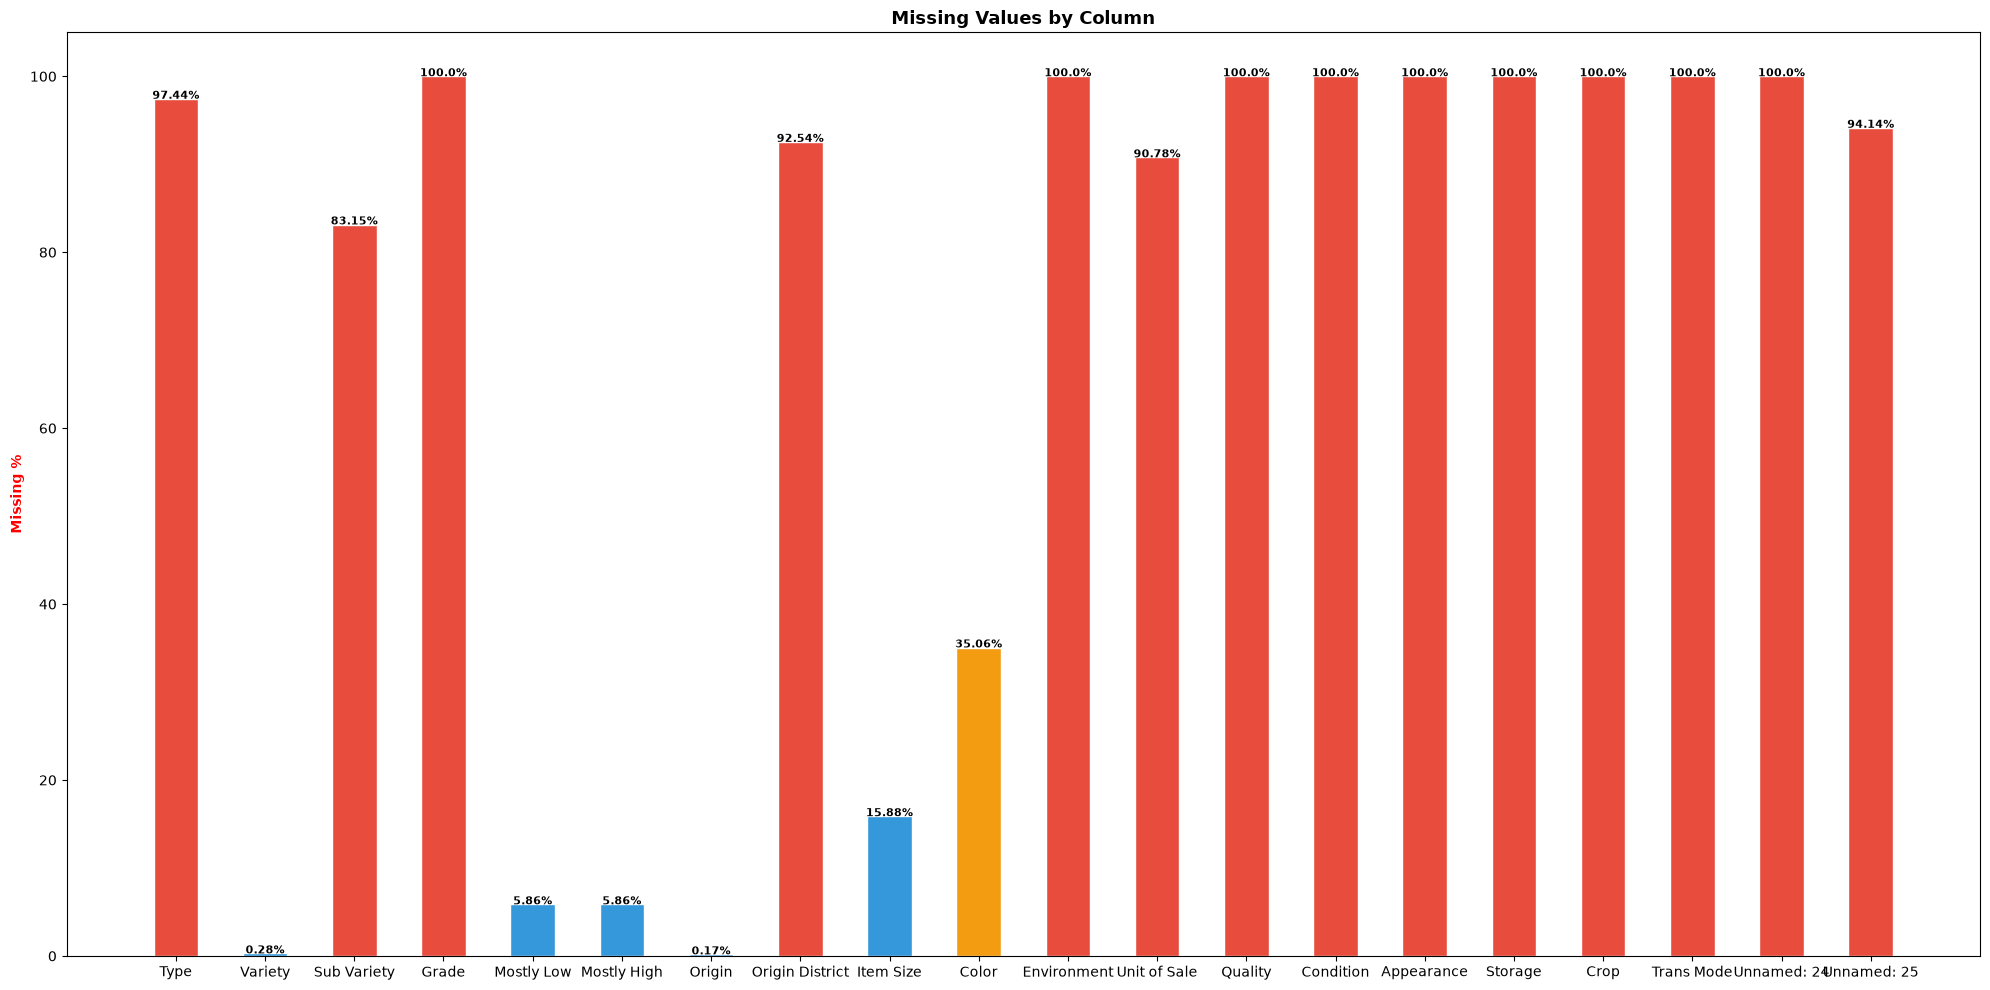

In [20]:
# Count missing values per column
missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %'    : missing_pct
})

print("=" * 50)
print("❗ MISSING VALUE REPORT")
print("=" * 50)
print(missing_report)

# Bar Chart for Missing Values
cols_with_missing = missing_report[missing_report['Missing Count'] > 0]

fig, ax = plt.subplots(figsize=(20, 10))
colors = ['#e74c3c' if v > 80 else '#f39c12' if v > 30 else '#3498db'
          for v in cols_with_missing['Missing %']]

bars = ax.bar(cols_with_missing.index, cols_with_missing['Missing %'],
              color=colors, edgecolor='white', width=0.5)

for bar, val in zip(bars, cols_with_missing['Missing %']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{val}%', ha='center', fontsize=8, fontweight='bold')

ax.set_ylabel("Missing %",color = "red",fontweight='bold')
ax.set_title("Missing Values by Column", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()